In [2]:
# dependency & Dlib 68-Landmark Model
!pip install imbalanced-learn opencv-python tensorflow scikit-learn matplotlib gTTS IPython dlib
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bzip2 -d shape_predictor_68_face_landmarks.dat.bz2

--2026-06-29 13:13:57--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-06-29 13:13:57--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  32.4MB/s    in 1.9s    

2026-06-29 13:13:59 (32.4 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

bzip2: Output file shape_predictor_68_face_landmarks.dat already exists.


In [3]:
import os
import cv2
import numpy as np
import tensorflow as tf
import dlib
import matplotlib.pyplot as plt
import base64
import html
import io
import time
import math
from IPython.display import display, Javascript, HTML, Audio
from google.colab.output import eval_js
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, Concatenate, BatchNormalization
from tensorflow.keras.models import Model
from PIL import Image

# Inisialisasi Dlib Face Detector & Landmark Predictor
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

# Indeks Landmark Wajah (Dlib 68-points)
LEFT_EYE = [36, 37, 38, 39, 40, 41]
RIGHT_EYE = [42, 43, 44, 45, 46, 47]
MOUTH = [48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67]

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import zipfile
os.makedirs('/content/dataset/train', exist_ok=True)
os.makedirs('/content/dataset/test', exist_ok=True)

train_zip_path = '/content/drive/MyDrive/Computer Vision Dataset/train.zip'
test_zip_path = '/content/drive/MyDrive/Computer Vision Dataset/test.zip'

print("Mengekstrak train.zip...")
with zipfile.ZipFile(train_zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset/train')

print("Mengekstrak test.zip...")
if os.path.exists(test_zip_path):
    with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/dataset/test')
else:
    print("test.zip tidak ditemukan. Akan dipisah otomatis dari train jika perlu.")

print("Ekstraksi selesai.")

Mengekstrak train.zip...
Mengekstrak test.zip...
Ekstraksi selesai.


In [6]:
# Dataset path
BASE_DIR = '/content/dataset'

TRAIN_DIR = os.path.join(BASE_DIR, 'train', 'train')

TEST_DIR = os.path.join(BASE_DIR, 'test', 'test')
if not os.path.exists(TEST_DIR):
    TEST_DIR = os.path.join(BASE_DIR, 'test')

if os.path.exists(TRAIN_DIR):
    CLASSES = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
    NUM_CLASSES = len(CLASSES)
    print(f"Berhasil Memperbaiki Path!")
    print(f"Ditemukan {NUM_CLASSES} kelas sesungguhnya: {CLASSES}")
else:
    print(f"[ERROR] Folder {TRAIN_DIR} tetap tidak ditemukan. Jalankan perintah '!find /content/dataset' di cell baru untuk cek struktur lengkapnya.")

Berhasil Memperbaiki Path!
Ditemukan 4 kelas sesungguhnya: ['Closed', 'Open', 'no_yawn', 'yawn']


In [7]:
# ambil hasil dari training

model_path_drive = '/content/drive/MyDrive/Computer Vision Dataset/saved_models/best_model_fold_5.keras'

if os.path.exists(model_path_drive):
    print("Inserting data")
    model_hybrid = tf.keras.models.load_model(model_path_drive)
else:
    print("No data")

Inserting data


In [8]:
#preproses & augmentasi
def calculate_ear(eye_points, landmarks):
    v1 = np.linalg.norm(np.array(landmarks[eye_points[1]]) - np.array(landmarks[eye_points[5]]))
    v2 = np.linalg.norm(np.array(landmarks[eye_points[2]]) - np.array(landmarks[eye_points[4]]))
    h = np.linalg.norm(np.array(landmarks[eye_points[0]]) - np.array(landmarks[eye_points[3]]))
    return (v1 + v2) / (2.0 * h) if h != 0 else 0

def calculate_mar(mouth_points, landmarks):
    v1 = np.linalg.norm(np.array(landmarks[51]) - np.array(landmarks[59]))
    v2 = np.linalg.norm(np.array(landmarks[52]) - np.array(landmarks[58]))
    v3 = np.linalg.norm(np.array(landmarks[53]) - np.array(landmarks[57]))
    h = np.linalg.norm(np.array(landmarks[48]) - np.array(landmarks[54]))
    return (v1 + v2 + v3) / (3.0 * h) if h != 0 else 0

def get_head_pose(landmarks, img_size):
    model_points = np.array([
        (0.0, 0.0, 0.0),             # Nose tip (30)
        (0.0, -330.0, -65.0),        # Chin (8)
        (-225.0, 170.0, -135.0),     # Left eye corner (36)
        (225.0, 170.0, -135.0),      # Right eye corner (45)
        (-150.0, -150.0, -125.0),    # Left mouth corner (48)
        (150.0, -150.0, -125.0)      # Right mouth corner (54)
    ], dtype="double")

    image_points = np.array([
        landmarks[30], landmarks[8], landmarks[36],
        landmarks[45], landmarks[48], landmarks[54]
    ], dtype="double")

    focal_length = img_size[1]
    center = (img_size[1]/2, img_size[0]/2)
    camera_matrix = np.array([[focal_length, 0, center[0]],
                              [0, focal_length, center[1]],
                              [0, 0, 1]], dtype="double")
    dist_coeffs = np.zeros((4,1))

    (success, rotation_vector, translation_vector) = cv2.solvePnP(
        model_points, image_points, camera_matrix, dist_coeffs, flags=cv2.SOLVEPNP_ITERATIVE)

    if not success: return 0, 0, 0


    rotation_matrix, _ = cv2.Rodrigues(rotation_vector)
    proj_matrix = np.hstack((rotation_matrix, translation_vector))
    euler_angles = cv2.decomposeProjectionMatrix(proj_matrix)[6]

    pitch = euler_angles[0][0]
    yaw = euler_angles[1][0]
    roll = euler_angles[2][0]
    return pitch, yaw, roll

def extract_features(img, augment=False):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if augment:
        if np.random.rand() > 0.5: img_rgb = cv2.flip(img_rgb, 1)
        if np.random.rand() > 0.5:
            h, w = img_rgb.shape[:2]
            M = cv2.getRotationMatrix2D((w/2, h/2), np.random.uniform(-15, 15), 1.0)
            img_rgb = cv2.warpAffine(img_rgb, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
        if np.random.rand() > 0.5:
            img_rgb = cv2.convertScaleAbs(img_rgb, alpha=np.random.uniform(0.7, 1.3), beta=np.random.uniform(-30, 30))
        if np.random.rand() > 0.5:
            img_rgb = cv2.add(img_rgb, np.random.normal(0, 5, img_rgb.shape).astype(np.uint8))

    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    faces = detector(gray)

    geom_features = np.zeros(5, dtype=np.float32)
    coords = None

    if len(faces) > 0:
        face = faces[0]
        shape = predictor(gray, face)
        landmarks = [(shape.part(i).x, shape.part(i).y) for i in range(68)]
        coords = landmarks

        left_ear = calculate_ear(LEFT_EYE, landmarks)
        right_ear = calculate_ear(RIGHT_EYE, landmarks)
        geom_features[0] = (left_ear + right_ear) / 2.0

        geom_features[1] = calculate_mar(MOUTH, landmarks)

        pitch, yaw, roll = get_head_pose(landmarks, gray.shape)
        geom_features[2] = pitch
        geom_features[3] = yaw
        geom_features[4] = roll

    img_norm = cv2.resize(img_rgb, (224, 224)) / 255.0
    return img_norm, geom_features, coords

class ProposalDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, filepaths, labels, batch_size=32, augment=False):
        self.filepaths = filepaths
        self.labels = labels
        self.batch_size = batch_size
        self.augment = augment
        self.indexes = np.arange(len(self.filepaths))
        if self.augment: np.random.shuffle(self.indexes)

    def __len__(self): return int(np.ceil(len(self.filepaths) / float(self.batch_size)))

    def on_epoch_end(self):
        if self.augment: np.random.shuffle(self.indexes)

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_filepaths = self.filepaths[batch_indexes]
        batch_labels = self.labels[batch_indexes]

        X_img = np.empty((len(batch_filepaths), 224, 224, 3), dtype=np.float32)
        X_geom = np.empty((len(batch_filepaths), 5), dtype=np.float32)

        for i, filepath in enumerate(batch_filepaths):
            img = cv2.imread(filepath)
            if img is not None:
                img_norm, geom, _ = extract_features(img, augment=self.augment)
                X_img[i] = img_norm
                X_geom[i] = geom

        y_cat = tf.keras.utils.to_categorical(batch_labels, num_classes=NUM_CLASSES)
        return (X_img, X_geom), y_cat

In [9]:
#modeling
def create_hybrid_model(learning_rate=0.0001, dropout_rate=0.5):
    img_input = Input(shape=(224, 224, 3), name='image_input')
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=img_input)

    for layer in base_model.layers: layer.trainable = False
    for layer in base_model.layers[-20:]: layer.trainable = True

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    img_features = Dense(128, activation='relu')(x)
    img_features = Dropout(dropout_rate)(img_features)

    geom_input = Input(shape=(5,), name='geom_input')
    geom_features = Dense(32, activation='relu')(geom_input)
    geom_features = Dropout(dropout_rate)(geom_features)

    concat = Concatenate()([img_features, geom_features])
    dense1 = Dense(64, activation='relu')(concat)
    dense1 = Dropout(dropout_rate)(dense1)

    output = Dense(NUM_CLASSES, activation='softmax', name='prediction')(dense1)

    model = Model(inputs=[img_input, geom_input], outputs=output)

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')])
    return model

In [10]:
# #training
# #skip aja cell ini cuk
# import glob

# print("Mengumpulkan paths secara rekursif...")
# filepaths = []
# labels = []
# class_indices = {c: i for i, c in enumerate(CLASSES)}

# for c in CLASSES:
#     search_pattern = os.path.join(TRAIN_DIR, f"**/{c}/*")
#     found_files = glob.glob(search_pattern, recursive=True)

#     for f in found_files:
#         if f.lower().endswith(('.png', '.jpg', '.jpeg')):
#             filepaths.append(f)
#             labels.append(class_indices[c])

# filepaths = np.array(filepaths)
# labels = np.array(labels)

# print(f"Total file gambar yang berhasil ditemukan: {len(filepaths)}")

# if len(filepaths) == 0:
#     print("\n[CRITICAL ERROR] Gambar tidak ditemukan!")
#     print(f"Coba cek isi direktori TRAIN_DIR Anda saat ini. Isinya adalah: {os.listdir(TRAIN_DIR)}")
#     print("Pastikan struktur folder di dalam drive/zip sudah benar.")
# else:
#     EPOCHS = 15
#     BATCH_SIZE = 32
#     K_FOLDS = 5

#     skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
#     fold = 1
#     histories = []

#     for train_idx, val_idx in skf.split(filepaths, labels):
#         print(f"\n{'='*20} Memulai Fold {fold} {'='*20}")
#         train_files, val_files = filepaths[train_idx], filepaths[val_idx]
#         train_labels, val_labels = labels[train_idx], labels[val_idx]

#         weights = class_weight.compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
#         c_weights = dict(enumerate(weights))
#         print(f"Class Weights untuk Imbalance (Fold {fold}): {c_weights}")

#         train_gen = ProposalDataGenerator(train_files, train_labels, batch_size=BATCH_SIZE, augment=True)
#         val_gen = ProposalDataGenerator(val_files, val_labels, batch_size=BATCH_SIZE, augment=False)

#         model = create_hybrid_model()

#         checkpoint = tf.keras.callbacks.ModelCheckpoint(
#             f'best_model_fold_{fold}.keras',
#             monitor='val_recall',
#             mode='max',
#             save_best_only=True
#         )
#         early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

#         history = model.fit(
#             train_gen,
#             validation_data=val_gen,
#             epochs=EPOCHS,
#             class_weight=c_weights,
#             callbacks=[checkpoint, early_stopping]
#         )
#         histories.append(history)
#         fold += 1

In [11]:

import glob
from sklearn.model_selection import StratifiedKFold

print("Mengumpulkan kembali paths untuk kebutuhan evaluasi...")
filepaths = []
labels = []
class_indices = {c: i for i, c in enumerate(CLASSES)}

for c in CLASSES:
    search_pattern = os.path.join(TRAIN_DIR, f"**/{c}/*")
    found_files = glob.glob(search_pattern, recursive=True)
    for f in found_files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            filepaths.append(f)
            labels.append(class_indices[c])

filepaths = np.array(filepaths)
labels = np.array(labels)

print(f"Total gambar ditemukan: {len(filepaths)}")

K_FOLDS = 5
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

for train_idx, val_idx in skf.split(filepaths, labels):
    val_files = filepaths[val_idx]
    val_labels = labels[val_idx]
    break

print(f"Variabel 'val_files' ({len(val_files)} data) dan 'val_labels' berhasil dipulihkan!")

Mengumpulkan kembali paths untuk kebutuhan evaluasi...
Total gambar ditemukan: 2467
Variabel 'val_files' (494 data) dan 'val_labels' berhasil dipulihkan!


In [12]:
# #evaluasi
# print("Evaluasi Fold Terbaik dan Perbandingan...")
# best_model = tf.keras.models.load_model('best_model_fold_1.keras')
# test_gen = ProposalDataGenerator(val_files, val_labels, batch_size=BATCH_SIZE, augment=False)

# predictions = best_model.predict(test_gen)
# y_pred_dl = np.argmax(predictions, axis=1)
# y_true = val_labels

# print("\n--- Evaluasi Model Hybrid (Deep Learning + Geometris) ---")
# print(classification_report(y_true, y_pred_dl, target_names=CLASSES))
# print("Confusion Matrix:")
# print(confusion_matrix(y_true, y_pred_dl))

# print("\n--- Mengekstrak fitur untuk evaluasi baseline tradisional ---")
# geom_list, true_labels = [], []
# for img_path, label in zip(val_files, val_labels):
#     img = cv2.imread(img_path)
#     if img is not None:
#         _, geom, _ = extract_features(img, augment=False)
#         geom_list.append(geom)
#         true_labels.append(label)

# X_geom_base = np.array(geom_list)
# y_base = np.array(true_labels)

# smote = SMOTE(random_state=42)
# X_geom_smote, y_smote = smote.fit_resample(X_geom_base, y_base)

# y_pred_trad = []
# for geom in X_geom_smote:
#     ear = geom[0]
#     mar = geom[1]
#     if ear <= 0.22:
#         y_pred_trad.append(CLASSES.index('Closed'))
#     elif mar > 0.45:
#         y_pred_trad.append(CLASSES.index('yawn') if 'yawn' in CLASSES else CLASSES.index('Closed'))
#     else:
#         y_pred_trad.append(CLASSES.index('Open') if 'Open' in CLASSES else CLASSES.index('Alert'))

# print("\n--- Evaluasi Baseline Tradisional (Algoritma EAR/MAR Murni dengan SMOTE) ---")
# print(classification_report(y_smote, y_pred_trad, target_names=CLASSES))
# CELL 12 & 13: Evaluasi dan Perbandingan (LOAD MODEL DARI DRIVE)

BATCH_SIZE = 32

print("Evaluasi Fold Terbaik dan Perbandingan...")
print("Evaluasi Fold Terbaik dan Perbandingan...")

model_path_drive = '/content/drive/MyDrive/Computer Vision Dataset/saved_models/best_model_fold_5.keras'

if not os.path.exists(model_path_drive):
    print(f"\n[CRITICAL ERROR] File model tidak ditemukan di: {model_path_drive}")
    print("Silakan cek Google Drive Anda, pastikan file 'best_model_fold_5.keras' ada di dalam folder tersebut.")
else:
    print("Model ditemukan di Google Drive! Memuat model...")
    best_model = tf.keras.models.load_model(model_path_drive)
    test_gen = ProposalDataGenerator(val_files, val_labels, batch_size=BATCH_SIZE, augment=False)

    predictions = best_model.predict(test_gen)
    y_pred_dl = np.argmax(predictions, axis=1)
    y_true = val_labels

    print("\n--- Evaluasi Model Hybrid (Deep Learning + Geometris) ---")
    print(classification_report(y_true, y_pred_dl, target_names=CLASSES))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred_dl))

    print("\n--- Mengekstrak fitur untuk evaluasi baseline tradisional ---")
    geom_list, true_labels = [], []
    for img_path, label in zip(val_files, val_labels):
        img = cv2.imread(img_path)
        if img is not None:
            _, geom, _ = extract_features(img, augment=False)
            geom_list.append(geom)
            true_labels.append(label)

    X_geom_base = np.array(geom_list)
    y_base = np.array(true_labels)

    smote = SMOTE(random_state=42)
    X_geom_smote, y_smote = smote.fit_resample(X_geom_base, y_base)

    y_pred_trad = []
    for geom in X_geom_smote:
        ear = geom[0]
        mar = geom[1]
        if ear <= 0.22:
            y_pred_trad.append(CLASSES.index('Closed'))
        elif mar > 0.45:
            y_pred_trad.append(CLASSES.index('yawn') if 'yawn' in CLASSES else CLASSES.index('Closed'))
        else:
            y_pred_trad.append(CLASSES.index('Open') if 'Open' in CLASSES else CLASSES.index('no_yawn'))

    print("\n--- Evaluasi Baseline Tradisional (Algoritma EAR/MAR Murni dengan SMOTE) ---")
    print(classification_report(y_smote, y_pred_trad, target_names=CLASSES))

Evaluasi Fold Terbaik dan Perbandingan...
Evaluasi Fold Terbaik dan Perbandingan...
Model ditemukan di Google Drive! Memuat model...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


16/16 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step

--- Evaluasi Model Hybrid (Deep Learning + Geometris) ---
              precision    recall  f1-score   support

      Closed       0.99      0.99      0.99       124
        Open       0.99      0.99      0.99       123
     no_yawn       0.97      0.74      0.84       123
        yawn       0.79      0.98      0.87       124

    accuracy                           0.93       494
   macro avg       0.94      0.92      0.92       494
weighted avg       0.94      0.93      0.92       494

Confusion Matrix:
[[123   1   0   0]
 [  1 122   0   0]
 [  0   0  91  32]
 [  0   0   3 121]]

--- Mengekstrak fitur untuk evaluasi baseline tradisional ---

--- Evaluasi Baseline Tradisional (Algoritma EAR/MAR Murni dengan SMOTE) ---
              precision    recall  f1-score   support

      Closed       0.35      1.00      0.52       124
        Open       0.00      0.00      0.00       124
     no_yawn       0.00      0.00      0.00       124
        yawn  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['image_input', 'geom_input']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))', 'Tensor(shape=(1, 5))']
  warnings.warn(msg)


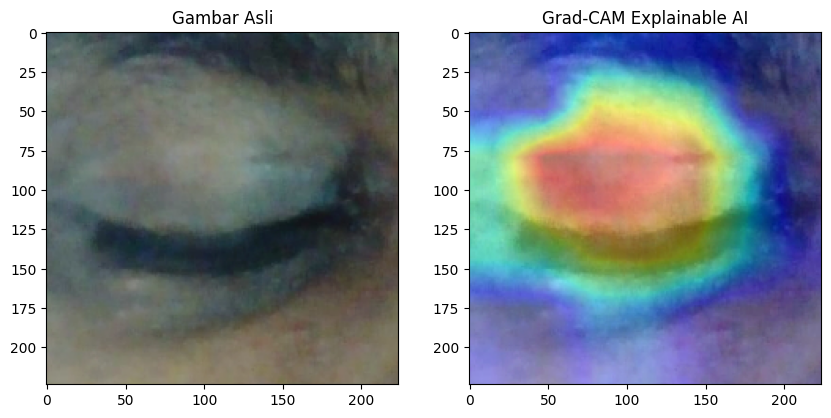

In [13]:
# Grad-CAM
def make_gradcam_heatmap(img_array, geom_array, model, last_conv_layer_name="out_relu"):
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model([img_array, geom_array])
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


sample_img_path = val_files[0]
img = cv2.imread(sample_img_path)
img_norm, geom_features, _ = extract_features(img, augment=False)

heatmap = make_gradcam_heatmap(np.expand_dims(img_norm, axis=0), np.expand_dims(geom_features, axis=0), best_model)

img_rgb = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (224, 224))
heatmap_resized = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)
jet = plt.colormaps.get_cmap("jet")
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap_resized]

superimposed_img = jet_heatmap * 0.4 + img_rgb / 255.0
superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Gambar Asli")
plt.imshow(img_rgb)
plt.subplot(1, 2, 2)
plt.title("Grad-CAM Explainable AI")
plt.imshow(superimposed_img)
plt.show()

In [14]:
# Testing

def init_webcam_js():
  js = Javascript('''
    var video;
    var div = null;
    var stream = null;
    var captureCanvas = null;
    var labelElement = null;
    var shutdown = false;
    var videoStream = null;

    window.removeDom = function() {
       shutdown = true;
       if (videoStream) {
         videoStream.getTracks().forEach(track => track.stop());
       }
       if (div) {
         div.parentNode.removeChild(div);
         div = null;
       }
    }

    window.createDom = function() {
      if (div !== null) return Promise.resolve("DOM ready");

      div = document.createElement('div');
      div.style.border = '2px solid #333';
      div.style.padding = '10px';
      div.style.width = '100%';
      div.style.maxWidth = '500px';
      div.style.margin = '0 auto';
      div.style.borderRadius = '8px';
      div.style.backgroundColor = '#f5f5f5';
      document.body.appendChild(div);

      const modelOut = document.createElement('div');
      modelOut.style.marginBottom = '10px';
      modelOut.style.textAlign = 'center';
      modelOut.innerHTML = "<span>Status: Menunggu Kamera...</span>";
      labelElement = modelOut.firstChild;
      div.appendChild(modelOut);

      video = document.createElement('video');
      video.style.display = 'block';
      video.style.width = '100%';
      video.style.borderRadius = '4px';
      video.setAttribute('playsinline', '');
      video.onclick = () => { shutdown = true; };
      div.appendChild(video);

      captureCanvas = document.createElement('canvas');
      captureCanvas.width = 640;
      captureCanvas.height = 480;

      window.overlayCanvas = document.createElement('canvas');
      window.overlayCanvas.width = 640;
      window.overlayCanvas.height = 480;
      window.overlayCanvas.style.position = 'absolute';
      window.overlayCanvas.style.pointerEvents = 'none';
      video.parentNode.appendChild(window.overlayCanvas);

      var audioCtx = new (window.AudioContext || window.webkitAudioContext)();
      window.playAlarm = function() {
          var oscillator = audioCtx.createOscillator();
          var gainNode = audioCtx.createGain();
          oscillator.type = 'square';
          oscillator.frequency.setValueAtTime(600, audioCtx.currentTime);
          oscillator.connect(gainNode);
          gainNode.connect(audioCtx.destination);
          oscillator.start();
          gainNode.gain.exponentialRampToValueAtTime(0.00001, audioCtx.currentTime + 0.2);
      }
      return navigator.mediaDevices.getUserMedia({video: true, audio: false})
      .then(function(s) {
        videoStream = s;
        video.srcObject = s;
        video.play();

        setTimeout(() => {
          window.overlayCanvas.style.top = video.offsetTop + 'px';
          window.overlayCanvas.style.left = video.offsetLeft + 'px';
          window.overlayCanvas.style.width = video.clientWidth + 'px';
          window.overlayCanvas.style.height = video.clientHeight + 'px';
        }, 1000);

        return "Kamera Berhasil Dimuat";
      });
    }

    window.drawLandmarksJS = function(coordsJson, statusColor) {
       var ctx = window.overlayCanvas.getContext('2d');
       ctx.clearRect(0, 0, 640, 480);

       if (!coordsJson) return;
       var coords = JSON.parse(coordsJson);

       if (statusColor === "red") {
          ctx.strokeStyle = "red";
          ctx.lineWidth = 8;
          ctx.strokeRect(0, 0, 640, 480);
       }

       ctx.fillStyle = statusColor === "red" ? "red" : "#00ff00";
       for (var i = 0; i < coords.length; i++) {
          ctx.beginPath();
          ctx.arc(coords[i][0], coords[i][1], 2.5, 0, 2 * Math.PI);
          ctx.fill();
       }
    }

    window.captureFrame = function(statusText, triggerAlarm) {
       return new Promise(function(resolve, reject) {
          if (shutdown) {
             window.removeDom();
             resolve(null);
             return;
          }
          if (triggerAlarm) window.playAlarm();
          labelElement.innerHTML = statusText;
          captureCanvas.getContext('2d').drawImage(video, 0, 0, 640, 480);
          resolve(captureCanvas.toDataURL('image/jpeg', 0.75));
       });
    }
    ''')
  display(js)

def js_to_image(js_reply):
  image_bytes = base64.b64decode(js_reply.split(',')[1])
  jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
  return cv2.imdecode(jpg_as_np, flags=1)

print("1. Menginisialisasi Environment JavaScript...")
init_webcam_js()
cam_status = eval_js('window.createDom()')
#ambil dari drive
model_path_drive = '/content/drive/MyDrive/Computer Vision Dataset/saved_models/best_model_fold_5.keras'
if not os.path.exists(model_path_drive):
    raise ValueError(f"ulang training cuk, kaga nemu hasil di drive {model_path_drive}")
else:
    print("Model ditemukan di Google Drive! Memuat model untuk Real-time...")
    model_hybrid = tf.keras.models.load_model(model_path_drive)

ALARM_THRESHOLD = 2
EAR_THRESHOLD = 0.22
MAR_THRESHOLD = 0.58

FRAME_WINDOW = 2
ear_history = []
mar_history = []

closed_frames = 0
status_text = "Status: Sistem Bersiap"
trigger_alarm = False
status_color = "green"

import json

while True:
  try:
    js_reply = eval_js(f'window.captureFrame("{status_text}", {str(trigger_alarm).lower()})')
    if not js_reply: break

    frame = js_to_image(js_reply)
    trigger_alarm = False

    img_norm, geom_features, coords = extract_features(frame, augment=False)

    if coords is not None:
        eval_js(f'window.drawLandmarksJS(\'{json.dumps(coords)}\', "{status_color}")')
    else:
        eval_js('window.drawLandmarksJS(null, "green")')

    X_img = np.expand_dims(img_norm, axis=0)
    X_geom = np.expand_dims(geom_features, axis=0)
    preds = model_hybrid.predict([X_img, X_geom], verbose=0)[0]
    pred_idx = np.argmax(preds)
    pred_class = CLASSES[pred_idx]

    raw_ear = geom_features[0]
    raw_mar = geom_features[1]

    if coords is not None:
        ear_history.append(raw_ear)
        mar_history.append(raw_mar)
        if len(ear_history) > FRAME_WINDOW:
            ear_history.pop(0)
            mar_history.pop(0)
        smoothed_ear = np.mean(ear_history)
        smoothed_mar = np.mean(mar_history)
    else:
        smoothed_ear = raw_ear
        smoothed_mar = raw_mar

    if coords is not None:
        if smoothed_ear <= EAR_THRESHOLD:
            pred_class = 'Closed'

        elif smoothed_mar > MAR_THRESHOLD:
            pred_class = 'yawn'

        if (pred_class == 'yawn' or pred_class == 'Closed' and smoothed_ear > EAR_THRESHOLD) and smoothed_mar < 0.60:
            pred_class = 'no_yawn'

    if pred_class == 'Closed':
        closed_frames += 1

        if closed_frames >= ALARM_THRESHOLD:
            status_text = f"<b style='color:red; font-size:18px;'> WAKE UP (weyki wyki)! COUNTER: {closed_frames}</b>"
            trigger_alarm = True
            status_color = "red"
        else:
            status_text = f"<b style='color:green; font-size:18px;'> NORMAL | EAR: {smoothed_ear:.2f} | MAR: {smoothed_mar:.2f} | STATUS: CLOSED</b>"
            status_color = "green"

    elif pred_class == 'yawn':
        closed_frames = 0
        status_text = f"<b style='color:orange; font-size:18px;'> PERINGATAN - ANDA MENGUAP! | EAR: {smoothed_ear:.2f} | MAR: {smoothed_mar:.2f}</b>"
        trigger_alarm = False
        status_color = "orange"

    else:
        closed_frames = 0
        status_text = f"<b style='color:green; font-size:18px;'> NORMAL | EAR: {smoothed_ear:.2f} | MAR: {smoothed_mar:.2f} | STATUS: {pred_class.upper()}</b>"
        status_color = "green"

  except Exception as e:
    print(f"\nSistem Dihentikan: {e}")
    break

1. Menginisialisasi Environment JavaScript...


<IPython.core.display.Javascript object>

MessageError: NotAllowedError: Permission denied

In [ ]:

import shutil

drive_backup_dir = '/content/drive/MyDrive/Computer Vision Dataset/saved_models/'
os.makedirs(drive_backup_dir, exist_ok=True)

for fold in range(1, 6):
    model_name = f'best_model_fold_{fold}.keras'
    if os.path.exists(model_name):
        shutil.copy(model_name, os.path.join(drive_backup_dir, model_name))
        print(f" Berhasil backup {model_name} ke Google Drive!")
    else:
        print(f" {model_name} tidak ditemukan di lokal Colab (mungkin training terhenti/belum selesai).")